# Arquivo criado para realizar uma das sugestões de análise do README.
"Veja a evolução ao longo dos anos (2020 a 2024) de uma função para Maceió e compare com a média das capitais."

Neste caso, a função escolhida foi a 16 - Habitação.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# Encontrando o arquivo
raiz_do_projeto = Path.cwd().parent
caminho_db = raiz_do_projeto / "dados_otimizados" / "dados_otimizados.parquet"

# Lendo o arquivo
df = pd.read_parquet(caminho_db)

In [2]:
# Removendo a notação científica nos valores numéricos do Jupyter Notebook
pd.set_option('display.float_format', '{:,.2f}'.format)

Filtrando o DataFrame...

In [3]:
# Serão necessárias as colunas Conta, População, UF, Coluna, Função/Subfunção e Ano

df_filtrado = df[["Conta", "População", "UF", "Coluna", "Valor", "Função/Subfunção", "Ano"]]

# Condições de filtro
condicao_funcao = df_filtrado["Função/Subfunção"] == "Função"
condicao_estagios = df_filtrado["Coluna"].isin(["Despesas Empenhadas", "Despesas Pagas"])

# Aplicando os filtros
df_analise = df_filtrado[condicao_funcao & condicao_estagios]


Criada uma tabela dinâmica para melhor manipulação.

In [4]:
# Tabela dinâmica para agrupar os dados.
df_pivot = pd.pivot_table(
    df_analise, 
    index=["Conta", "População", "UF", "Ano"],
    columns="Coluna",
    values="Valor",
    aggfunc="sum"
    ).reset_index()

# Adicionando uma coluna para calcular a Taxa de Execução entre o Empenhado e o Pago
df_pivot["Taxa de Execução"] = ((df_pivot["Despesas Pagas"] / df_pivot["Despesas Empenhadas"]) * 100).fillna(0).replace([np.inf, -np.inf], 0)

# Adicionando coluna que calcula o Gargalo Per Capita, 
# métrica para mensurar a diferença entre o Empenhado e o Pago com o Per Capita das capitais
df_pivot["Gargalo Per Capita"] = ((df_pivot["Despesas Empenhadas"] - df_pivot["Despesas Pagas"]) / df_pivot["População"]).fillna(0)

A exibição é através de um gráfico de barras verticais feito com as bibliotecas seaborn e matplotlib.

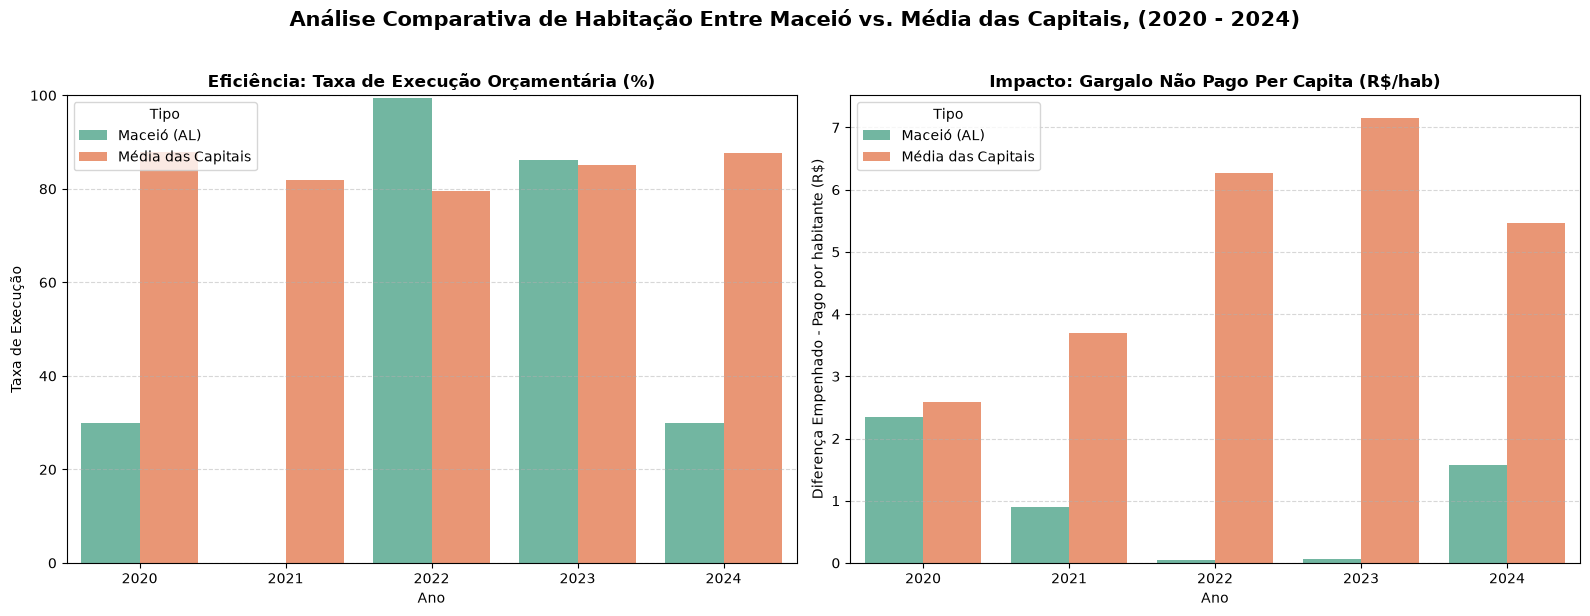

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Preparação e filtragem dos dados

# Definindo os parâmetros da nossa análise
funcao_alvo = "16 - Habitação"
anos_analise = [2020, 2021, 2022, 2023, 2024]

# Filtrando a base mãe para conter apenas a função e os anos desejados
df_funcao = df_pivot[
    (df_pivot["Conta"] == funcao_alvo) & 
    (df_pivot["Ano"].isin(anos_analise))
].copy()

# 2. Definição de variáveis para Maceió a média das capitais

# Variável 1: Isolando os dados específicos de Maceió (AL)
df_maceio = df_funcao[df_funcao["UF"] == "AL"][["Ano", "Taxa de Execução", "Gargalo Per Capita"]].copy()
df_maceio["Tipo"] = "Maceió (AL)"

# Variável 2: Calculando a média das capitais ano a ano (excluindo Maceió)
df_media_capitais = (
    df_funcao[df_funcao["UF"] != "AL"]
    .groupby("Ano")[["Taxa de Execução", "Gargalo Per Capita"]]
    .mean()
    .reset_index()
)
df_media_capitais["Tipo"] = "Média das Capitais"

# Juntando as duas visões em um único DataFrame
df_comparacao = pd.concat([df_maceio, df_media_capitais], ignore_index=True)

# 3. Construção do gráfico
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1
sns.barplot(
    data=df_comparacao,
    x="Ano",
    y="Taxa de Execução",
    hue="Tipo",
    palette="Set2",
    ax=ax1
)
ax1.set_title("Eficiência: Taxa de Execução Orçamentária (%)", fontsize=12, fontweight='bold')
ax1.set_xlabel("Ano", fontsize=10)
ax1.set_ylabel("Taxa de Execução", fontsize=10)
ax1.set_ylim(0, 100)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Gráfico 2 
sns.barplot(
    data=df_comparacao,
    x="Ano",
    y="Gargalo Per Capita",
    hue="Tipo",
    palette="Set2",
    ax=ax2
)
ax2.set_title("Impacto: Gargalo Não Pago Per Capita (R$/hab)", fontsize=12, fontweight='bold')
ax2.set_xlabel("Ano", fontsize=10)
ax2.set_ylabel("Diferença Empenhado - Pago por habitante (R$)", fontsize=10)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

# Título geral e Ajuste
fig.suptitle(f"Análise Comparativa de Habitação Entre Maceió vs. Média das Capitais, (2020 - 2024)", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()

# Exibindo o resultado final
plt.show()

Análise no [README](./README.md)